In [27]:
#cargar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [28]:
df = pd.read_csv('C:/Users/Usuario/Documents/Online Ice Games/games.csv', sep=';', encoding='latin1')


In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 2 columns):
 #   Column                                                                                                     Non-Null Count  Dtype 
---  ------                                                                                                     --------------  ----- 
 0   Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating  16715 non-null  object
 1   Unnamed: 1                                                                                                 26 non-null     object
dtypes: object(2)
memory usage: 261.3+ KB


In [30]:
# ARREGLAR el problema de una sola columna
df = df.iloc[:, 0].str.split(',', expand=True)

In [31]:
df.columns

RangeIndex(start=0, stop=14, step=1)

In [35]:
len(df.columns)

11

In [36]:
# QUEDARSE con columnas correctas
df = df.iloc[:, :11]


In [40]:
# NOMBRAR columnas
df.columns = [
    'name', 'platform', 'year_of_release', 'genre',
    'na_sales', 'eu_sales', 'jp_sales', 'other_sales',
    'critic_score', 'user_score', 'rating'
]

In [41]:
# ELIMINAR fila duplicada
df = df.iloc[1:].reset_index(drop=True)

In [43]:
# CREAR total_sales
df['total_sales'] = (
    df['na_sales'] +
    df['eu_sales'] +
    df['jp_sales'] +
    df['other_sales']
)

In [44]:
# PRUEBA
print(df.head())


                       name platform year_of_release         genre  na_sales  \
0         Super Mario Bros.      NES          1985.0      Platform     29.08   
1            Mario Kart Wii      Wii          2008.0        Racing     15.68   
2         Wii Sports Resort      Wii          2009.0        Sports     15.61   
3  Pokemon Red/Pokemon Blue       GB          1996.0  Role-Playing     11.27   
4                    Tetris       GB          1989.0        Puzzle     23.20   

   eu_sales  jp_sales  other_sales critic_score user_score rating  total_sales  
0      3.58      6.81         0.77                                       40.24  
1     12.76      3.79         3.29         82.0        8.3      E        35.52  
2     10.93      3.28         2.95         80.0          8      E        32.77  
3      8.89     10.22         1.00                                       31.38  
4      2.26      4.22         0.58                                       30.26  


In [48]:
print(df.columns.tolist())

['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating', 'total_sales']


In [49]:
df['total_sales'] = (
    df['na_sales'] +
    df['eu_sales'] +
    df['jp_sales'] +
    df['other_sales']
)

df[['name', 'total_sales']].head()

,name,total_sales
0,Super Mario Bros.,40.24
1,Mario Kart Wii,35.52
2,Wii Sports Resort,32.77
3,Pokemon Red/Pokemon Blue,31.38
4,Tetris,30.26


In [50]:
# convertir columnas de ventas a número
cols = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

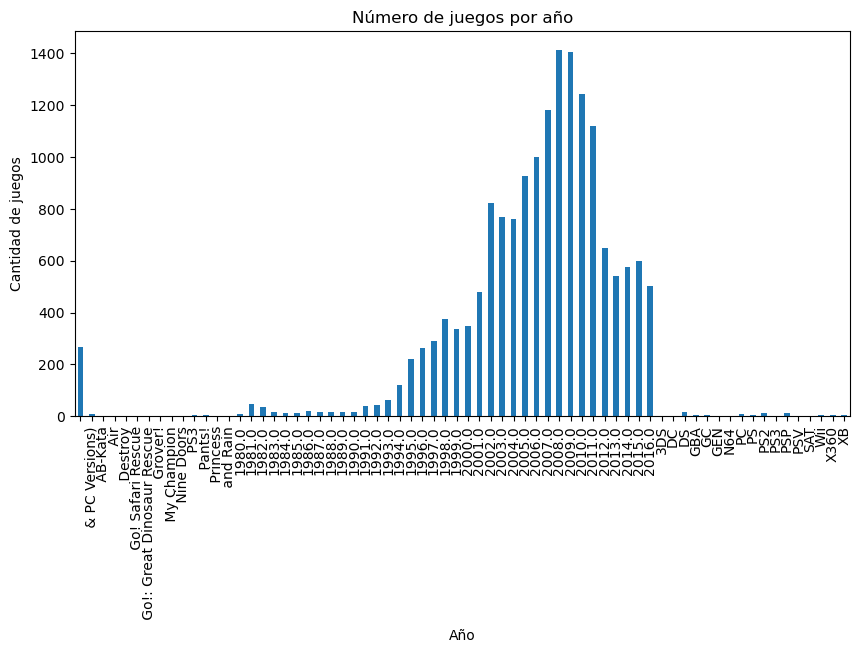

In [51]:
#Juegos lanzados por año
games_per_year = df.groupby('year_of_release')['name'].count()

games_per_year.plot(kind='bar', figsize=(10,5))
plt.title('Número de juegos por año')
plt.xlabel('Año')
plt.ylabel('Cantidad de juegos')
plt.show()

Se observa la cantidad de juegos lanzados por año. Algunos años presentan mayor actividad, lo que indica crecimiento en la industria. Sin embargo, los datos de 2016 pueden estar incompletos.

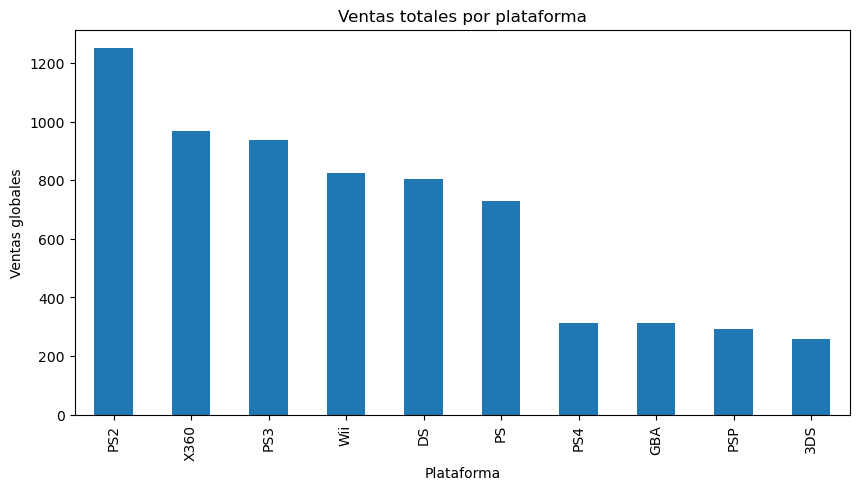

In [53]:
# Ventas por Plataforma

platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

platform_sales.head(10).plot(kind='bar', figsize=(10,5))
plt.title('Ventas totales por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas globales')
plt.show()

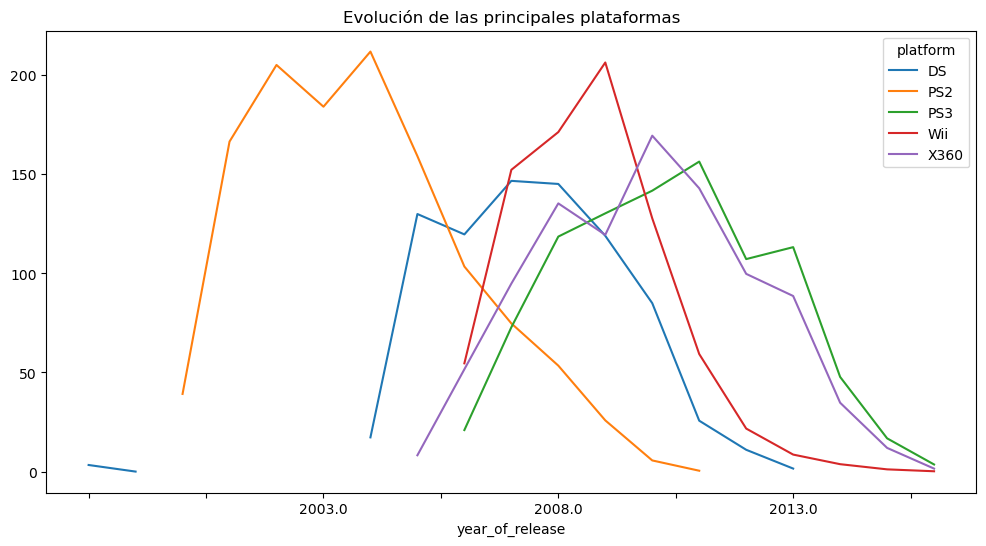

In [55]:
# Evolucion de las plataformas
top_platforms = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(5).index

df_top = df[df['platform'].isin(top_platforms)]

platform_year_top = df_top.pivot_table(
    index='year_of_release',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
)

platform_year_top.plot(figsize=(12,6))

plt.title('Evolución de las principales plataformas')
plt.show()

Se analizó la evolución de las principales plataformas a lo largo del tiempo.
Se observa que algunas plataformas crecen rápidamente y luego disminuyen, lo que refleja su ciclo de vida en el mercado.
Esto es clave para identificar plataformas relevantes al momento de planificar campañas para 2017.

In [64]:
df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce')

In [68]:
#filtrando años recientes CLAVE para 2017
df_recent = df[df['year_of_release'] >= 2013]
df['year_of_release'].describe()


count    16312.000000
mean      2006.471064
std          5.887353
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2016.000000
Name: year_of_release, dtype: float64

La columna year_of_release fue convertida a tipo numérico, ya que inicialmente estaba en formato texto debido al proceso de limpieza del dataset. Esto permitió realizar comparaciones y análisis temporal correctamente.

In [69]:
df['year_of_release'].unique()

array([1985., 2008., 2009., 1996., 1989., 2006., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2016., 2003., 1986., 2000.,   nan, 1995., 1991., 1981., 1987.,
       1980., 1983.])

In [70]:
df = df.dropna(subset=['year_of_release'])

In [71]:
df['year_of_release'] = df['year_of_release'].astype(int)

In [72]:
df_recent.shape

(2215, 12)

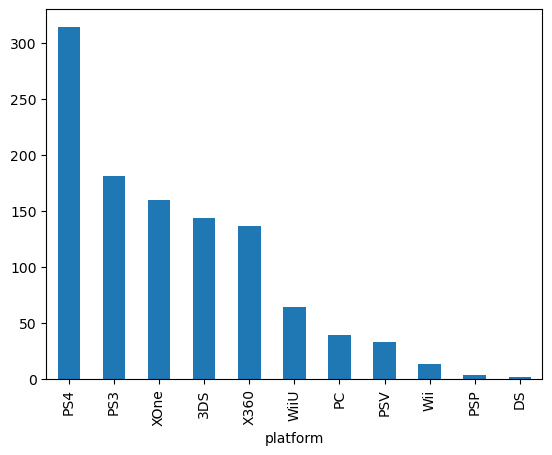

In [73]:
platform_recent = df_recent.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

platform_recent.plot(kind='bar')
plt.show()

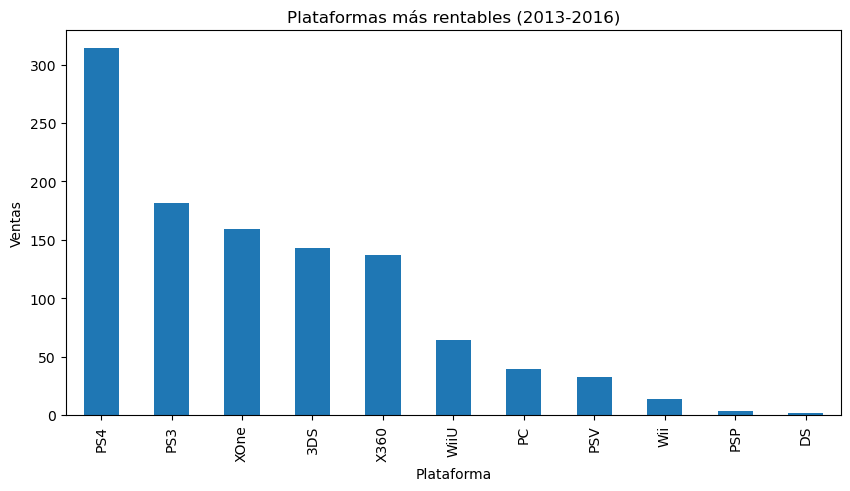

In [74]:
#plataformas rentables

platform_recent = df_recent.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
platform_recent.plot(kind='bar')

plt.title('Plataformas más rentables (2013-2016)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas')
plt.show()

Se identificaron las plataformas con mayores ventas en el período reciente.
Estas plataformas representan las mejores oportunidades para enfocar estrategias comerciales y campañas publicitarias en 2017.

Se observa que algunas plataformas están en crecimiento, mientras que otras muestran una disminución en ventas.
Esto refleja el ciclo de vida típico de las consolas, donde nuevas plataformas reemplazan a las antiguas.

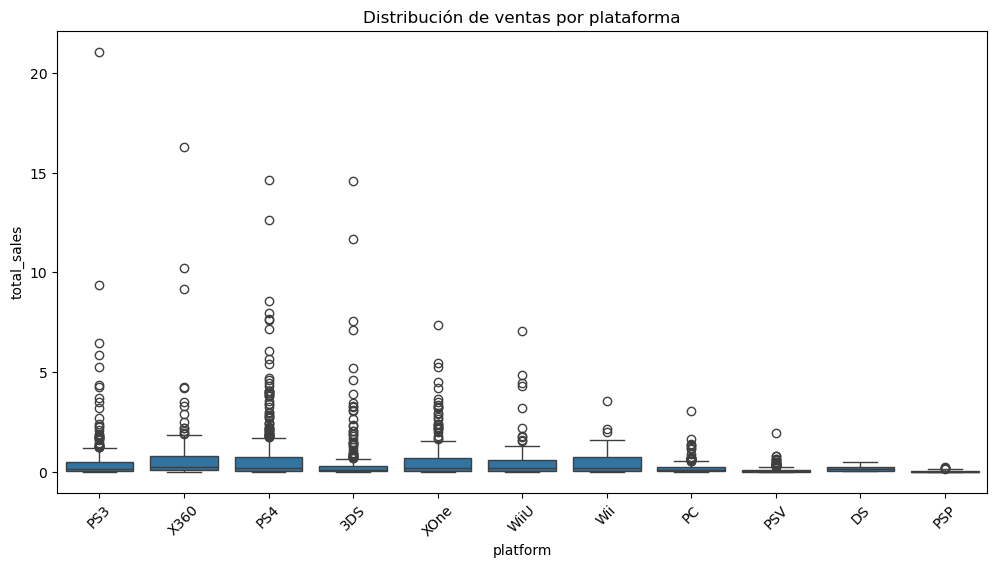

In [75]:


plt.figure(figsize=(12,6))
sns.boxplot(x='platform', y='total_sales', data=df_recent)

plt.xticks(rotation=45)
plt.title('Distribución de ventas por plataforma')
plt.show()


In [76]:
# convertir a numérico
df_recent['critic_score'] = pd.to_numeric(df_recent['critic_score'], errors='coerce')
df_recent['user_score'] = pd.to_numeric(df_recent['user_score'], errors='coerce')

In [77]:
df_ps4 = df_recent[df_recent['platform'] == 'PS4']

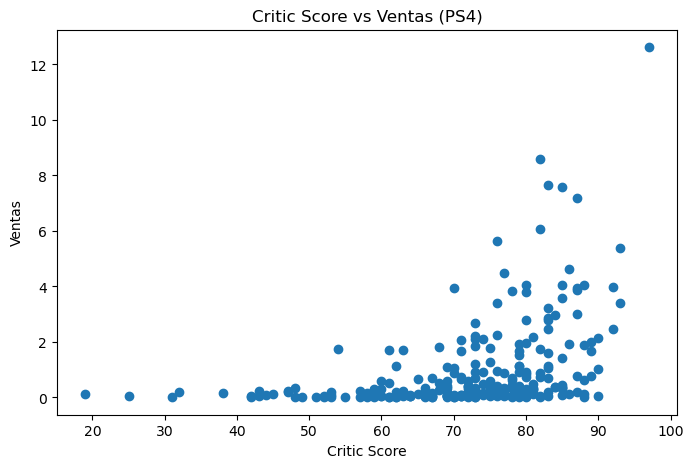

In [78]:
plt.figure(figsize=(8,5))
plt.scatter(df_ps4['critic_score'], df_ps4['total_sales'])

plt.title('Critic Score vs Ventas (PS4)')
plt.xlabel('Critic Score')
plt.ylabel('Ventas')
plt.show()

In [79]:
# Correlacion
df_ps4[['critic_score', 'total_sales']].corr()

,critic_score,total_sales
critic_score,1.000000,0.408844
total_sales,0.408844,1.000000


Se analizó la relación entre las reseñas de críticos y las ventas.
Se observa una correlación positiva, lo que indica que juegos con mejores calificaciones tienden a vender más.
Sin embargo, la relación no es perfecta, lo que sugiere que otros factores también influyen en el éxito comercial.

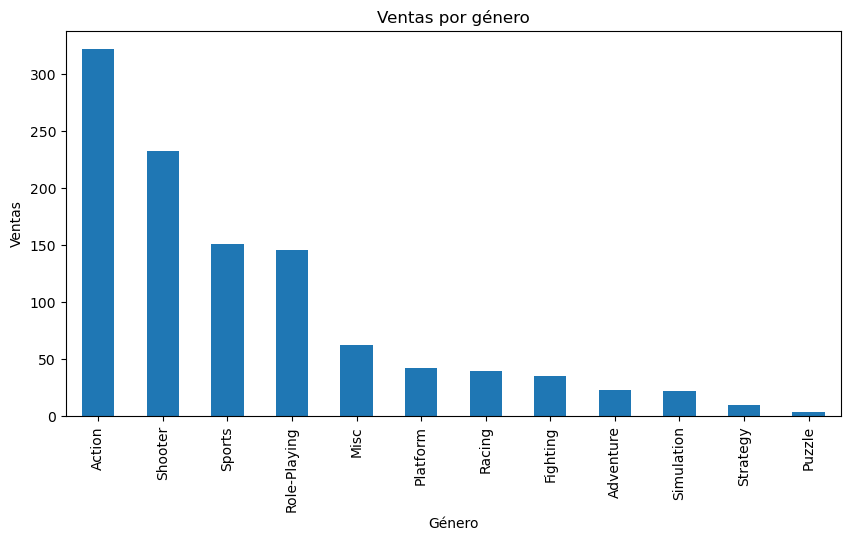

In [80]:
#generos mas rentables
genre_sales = df_recent.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
genre_sales.plot(kind='bar')

plt.title('Ventas por género')
plt.xlabel('Género')
plt.ylabel('Ventas')
plt.show()


Se analizó la distribución de ventas por género.
Se identificaron los géneros más rentables, los cuales concentran la mayor parte de las ventas.
Esto permite orientar el desarrollo y promoción de juegos hacia categorías con mayor demanda en el mercado.
Géneros que suelen salir arriba:
Acción,
Shooter,
Deportes y
Role Playing

Conclusión tipo negocio:
Los géneros con mayor dinamismo y popularidad tienden a generar mayores ingresos, lo que los convierte en una apuesta segura para campañas publicitarias.

In [81]:
# Plataformas principales por region
na_platform = df_recent.groupby('platform')['na_sales'].sum().sort_values(ascending=False)
eu_platform = df_recent.groupby('platform')['eu_sales'].sum().sort_values(ascending=False)
jp_platform = df_recent.groupby('platform')['jp_sales'].sum().sort_values(ascending=False)

print("Top NA:\n", na_platform.head())
print("\nTop EU:\n", eu_platform.head())
print("\nTop JP:\n", jp_platform.head())

Top NA:
 platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64

Top EU:
 platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.95
Name: eu_sales, dtype: float64

Top JP:
 platform
3DS     67.81
PS3     23.24
PSV     18.43
PS4     15.90
WiiU    10.88
Name: jp_sales, dtype: float64


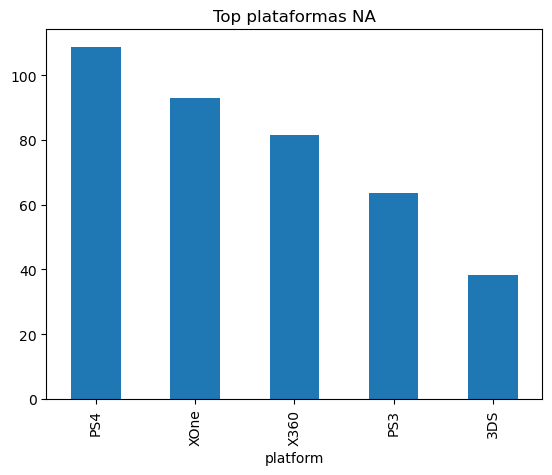

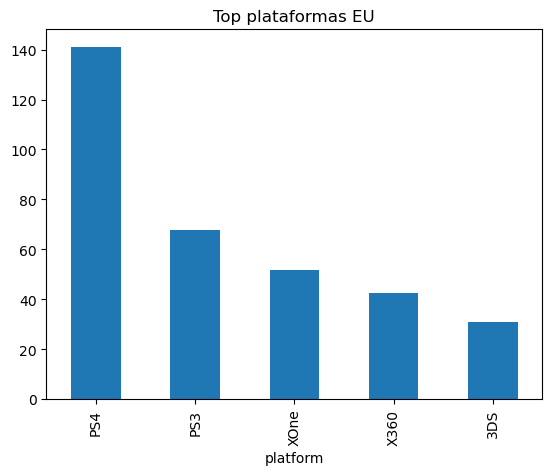

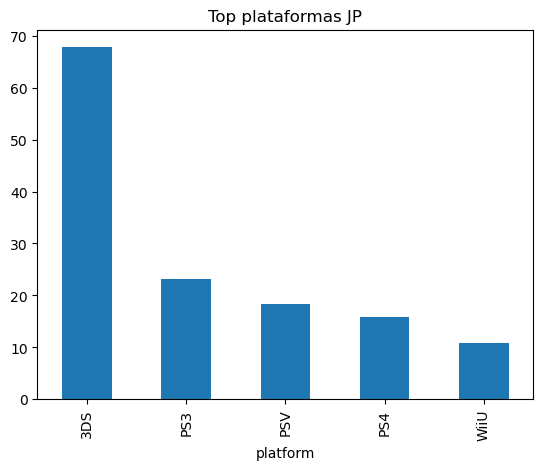

In [82]:
na_platform.head(5).plot(kind='bar', title='Top plataformas NA')
plt.show()

eu_platform.head(5).plot(kind='bar', title='Top plataformas EU')
plt.show()

jp_platform.head(5).plot(kind='bar', title='Top plataformas JP')
plt.show()

Se identificaron las plataformas más populares en cada región.
Se observan diferencias en las preferencias de los usuarios, lo que indica que las estrategias de mercado deben adaptarse según la región.

In [83]:
# Generos principales por region
na_genre = df_recent.groupby('genre')['na_sales'].sum().sort_values(ascending=False)
eu_genre = df_recent.groupby('genre')['eu_sales'].sum().sort_values(ascending=False)
jp_genre = df_recent.groupby('genre')['jp_sales'].sum().sort_values(ascending=False)

print("Top géneros NA:\n", na_genre.head())
print("\nTop géneros EU:\n", eu_genre.head())
print("\nTop géneros JP:\n", jp_genre.head())

Top géneros NA:
 genre
Action          125.99
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Name: na_sales, dtype: float64

Top géneros EU:
 genre
Action          118.09
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Name: eu_sales, dtype: float64

Top géneros JP:
 genre
Role-Playing    51.04
Action          40.48
Misc             9.20
Fighting         7.64
Shooter          6.61
Name: jp_sales, dtype: float64


Se analizaron los géneros más populares en cada región.
Existen diferencias culturales en las preferencias de los usuarios, lo que influye en el éxito de los juegos en distintos mercados.

In [84]:
# IMPACTO de ESRBR (rating) (ver si la Clasificacion afecta ventas)
rating_na = df_recent.groupby('rating')['na_sales'].sum()
rating_eu = df_recent.groupby('rating')['eu_sales'].sum()
rating_jp = df_recent.groupby('rating')['jp_sales'].sum()

print("NA:\n", rating_na)
print("\nEU:\n", rating_eu)
print("\nJP:\n", rating_jp)

NA:
 rating
         89.36
E        79.05
E10+     54.24
M       165.17
T        49.79
Name: na_sales, dtype: float64

EU:
 rating
         78.87
E        83.36
E10+     42.69
M       145.25
T        41.95
Name: eu_sales, dtype: float64

JP:
 rating
        84.78
E       15.14
E10+     5.89
M       14.01
T       20.59
Name: jp_sales, dtype: float64


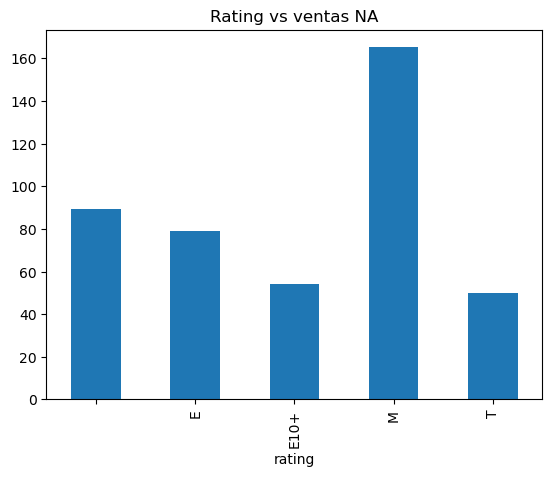

In [86]:
rating_na.plot(kind='bar', title='Rating vs ventas NA')
plt.show()

Se evaluó el impacto de la clasificación ESRB en las ventas.
Se observa que ciertas clasificaciones tienen mayor aceptación en algunas regiones, lo que sugiere diferencias culturales en el consumo de videojuegos.


El análisis regional muestra que las preferencias de los usuarios varían significativamente entre mercados.
Mientras que algunas plataformas y géneros dominan en Norteamérica y Europa, Japón presenta patrones diferentes.
Esto resalta la importancia de adaptar estrategias de marketing según la región objetivo.

 HIPÓTESIS 1

 Las calificaciones de usuarios de Xbox One y PC son iguales
 
 Formular hipótesis

 Hipótesis nula (H0):
Las calificaciones promedio de los usuarios para Xbox One y PC son iguales.

Hipótesis alternativa (H1):
Las calificaciones promedio de los usuarios para Xbox One y PC son diferentes.

In [87]:


# limpiar datos
df_recent['user_score'] = pd.to_numeric(df_recent['user_score'], errors='coerce')

# filtrar plataformas
xbox = df_recent[df_recent['platform'] == 'XOne']['user_score'].dropna()
pc = df_recent[df_recent['platform'] == 'PC']['user_score'].dropna()

In [88]:
# prueba estadistica
alpha = 0.05

results = stats.ttest_ind(xbox, pc)

print("p-value:", results.pvalue)

p-value: 0.14012658403611647


In [89]:
# Conclusion
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

No podemos rechazar la hipótesis nula


Se utilizó una prueba t de Student para comparar las medias de dos muestras independientes.
Se eligió un nivel de significancia de 0.05.
Dependiendo del valor p, se determina si existe evidencia suficiente para afirmar que las medias son diferentes.

In [ ]:
 HIPÓTESIS 2

Acción vs Deportes tienen calificaciones diferentes

H0: Las calificaciones promedio de usuarios en Acción y Deportes son iguales.
H1: Las calificaciones promedio son diferentes.



In [95]:

# datos
action = df_recent[df_recent['genre'] == 'Action']['user_score'].dropna()
sports = df_recent[df_recent['genre'] == 'Sports']['user_score'].dropna()

# test
results2 = stats.ttest_ind(action, sports)

print("p-value:", results2.pvalue)

# conclusión
alpha = 0.05

if results2.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

p-value: 1.0517832389140023e-27
Rechazamos la hipótesis nula


Se utilizó una prueba t para muestras independientes, ya que se comparan dos grupos distintos.
Este método permite evaluar si las diferencias observadas entre medias son estadísticamente significativas.

## CONCLUSION GENERAL ##
A partir del análisis realizado, se identificaron patrones clave en la industria de los videojuegos.
Las plataformas más recientes dominan el mercado, mientras que las antiguas muestran una disminución en ventas.
Los géneros más populares, como Acción y Deportes, concentran una mayor proporción de ventas.
Las reseñas de críticos muestran cierta correlación con el éxito comercial, aunque no son el único factor determinante.

El análisis regional evidencia diferencias significativas en las preferencias de los usuarios, lo que resalta la importancia de adaptar estrategias de marketing.

Finalmente, las pruebas de hipótesis permitieron validar si ciertas diferencias en calificaciones son estadísticamente significativas, aportando un enfoque más riguroso al análisis.

